In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
sentiment = pd.read_csv('/content/fear_greed_index.csv')
trades = pd.read_csv('/content/historical_data.csv')

In [20]:
print("Sentiment Shape:", sentiment.shape)
print("Trader Data Shape:", trades.shape)
print("Sentiment Columns:")
print(sentiment.columns)
print("Trader Columns:")
print(trades.columns)

Sentiment Shape: (2644, 4)
Trader Data Shape: (211224, 16)
Sentiment Columns:
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Trader Columns:
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [21]:
print("Sentiment Missing Values")
print(sentiment.isnull().sum())
print("Trader Missing Values")
print(trades.isnull().sum())
print("Sentiment duplicates:", sentiment.duplicated().sum())
print("Trader duplicates:", trades.duplicated().sum())

Sentiment Missing Values
timestamp         0
value             0
classification    0
date              0
dtype: int64
Trader Missing Values
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
Sentiment duplicates: 0
Trader duplicates: 0


In [22]:
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit='ms')
trades['date'] = trades['Timestamp'].dt.date

In [23]:
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

In [49]:
data = trades.merge(sentiment[['date','classification']],on='date',how='left')
data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27,Greed


In [26]:
daily_pnl = data.groupby(['Account','date'])['Closed PnL'].sum().reset_index()
daily_pnl.rename(columns={'Closed PnL':'daily_pnl'}, inplace=True)

In [27]:
trades_per_day = data.groupby(['Account','date']).size().reset_index(name='num_trades')

In [28]:
avg_trade_size = data.groupby(['Account','date'])['Size USD'].mean().reset_index()

In [52]:
data['leverage'] = (data['Size Tokens'] * data['Execution Price']) / data['Size USD']
leverage_threshold = data['leverage'].median()
data['leverage_segment'] = np.where(
    data['leverage'] > leverage_threshold,
    'High Leverage',
    'Low Leverage'
)

print(f"Leverage Threshold (Median): {leverage_threshold:.2f}x")
data[['Account', 'leverage', 'leverage_segment']].head()

Leverage Threshold (Median): 1.00x


,Account,leverage,leverage_segment
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,1.000000,High Leverage
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,1.000000,Low Leverage
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,1.000001,High Leverage
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,0.999999,Low Leverage
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,0.999964,Low Leverage


In [29]:
data['size_segment'] = np.where(
    data['Size USD'] > data['Size USD'].median(),
    'Large Trade',
    'Small Trade'
)

In [30]:
metrics = daily_pnl.merge(trades_per_day,on=['Account','date'])
metrics = metrics.merge(avg_trade_size,on=['Account','date'])

metrics = metrics.merge(
    sentiment[['date','classification']],
    on='date',
    how='left'
)
metrics.head()

,Account,date,daily_pnl,num_trades,Size USD,classification
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,-3.275059e+05,462,14810.891818,Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1.927736e+06,3356,16345.241940,Fear
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,2.060745e+04,320,2492.749906,Greed
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,1.709873e+04,3533,1693.351684,Fear
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-06-15,1.017915e+04,3427,1533.468395,NaN


In [31]:
metrics.groupby('classification')['daily_pnl'].mean()

,daily_pnl
classification,
Extreme Greed,35393.098355
Fear,209372.662205
Greed,99675.516731
Neutral,19842.797260


In [33]:
metrics['win'] = metrics['daily_pnl'] > 0
win_rate = metrics.groupby('classification')['win'].mean()
print(win_rate)

classification
Extreme Greed    0.40000
Fear             0.93750
Greed            0.84375
Neutral          0.50000
Name: win, dtype: float64


In [34]:
metrics.groupby('classification')['num_trades'].mean()

,num_trades
classification,
Extreme Greed,1392.40000
Fear,4183.46875
Greed,1134.03125
Neutral,892.62500


In [35]:
metrics.groupby('classification')['Size USD'].mean()

,Size USD
classification,
Extreme Greed,4344.447836
Fear,5926.522723
Greed,5839.310974
Neutral,3793.444161


Text(0.5, 1.0, 'Avg Profit: High vs Low Leverage')

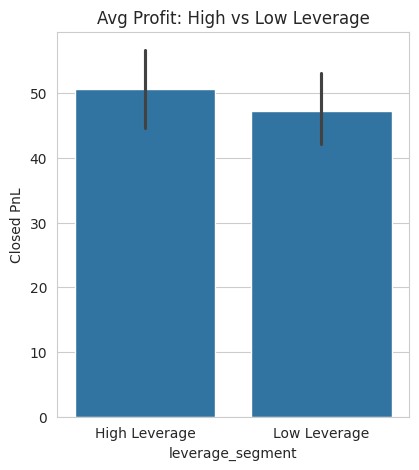

In [53]:
lev_metrics = data.groupby('leverage_segment').agg({
    'Closed PnL': 'mean',
    'Size USD': 'mean',
    'Account': 'nunique'
}).reset_index()

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.barplot(data=data, x='leverage_segment', y='Closed PnL')
plt.title("Avg Profit: High vs Low Leverage")

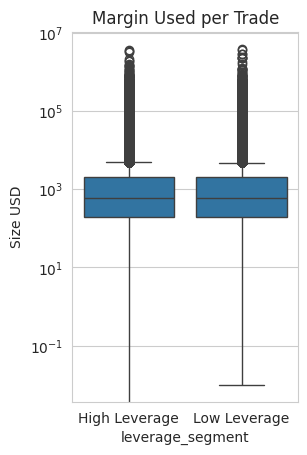

In [54]:
plt.subplot(1, 2, 2)
sns.boxplot(data=data, x='leverage_segment', y='Size USD')
plt.title("Margin Used per Trade")
plt.yscale('log')
plt.show()

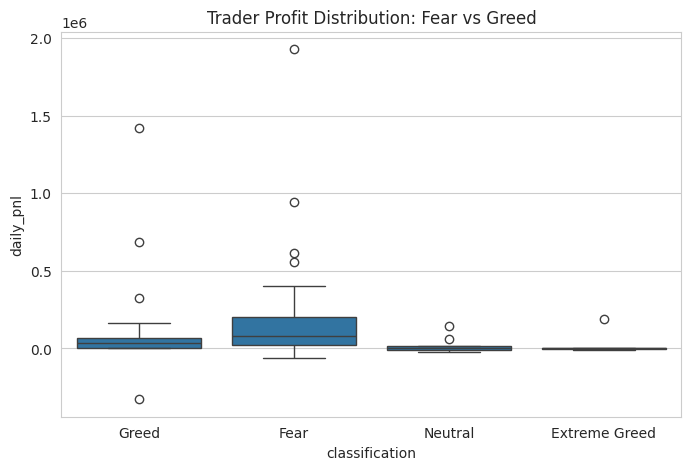

In [36]:
plt.figure(figsize=(8,5))
sns.boxplot(data=metrics, x='classification', y='daily_pnl')
plt.title("Trader Profit Distribution: Fear vs Greed")
plt.show()

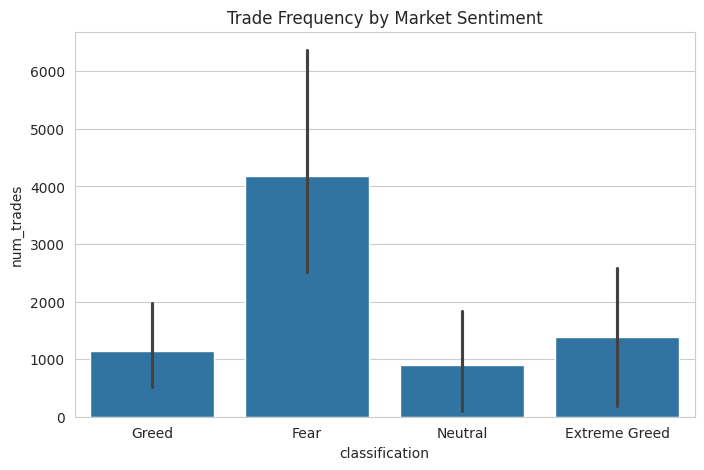

In [37]:
plt.figure(figsize=(8,5))
sns.barplot(data=metrics, x='classification', y='num_trades')
plt.title("Trade Frequency by Market Sentiment")
plt.show()

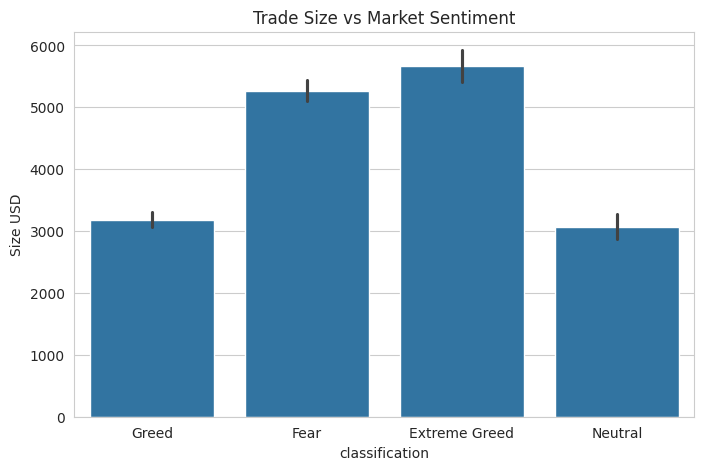

In [38]:
plt.figure(figsize=(8,5))
sns.barplot(data=data, x='classification', y='Size USD')
plt.title("Trade Size vs Market Sentiment")
plt.show()

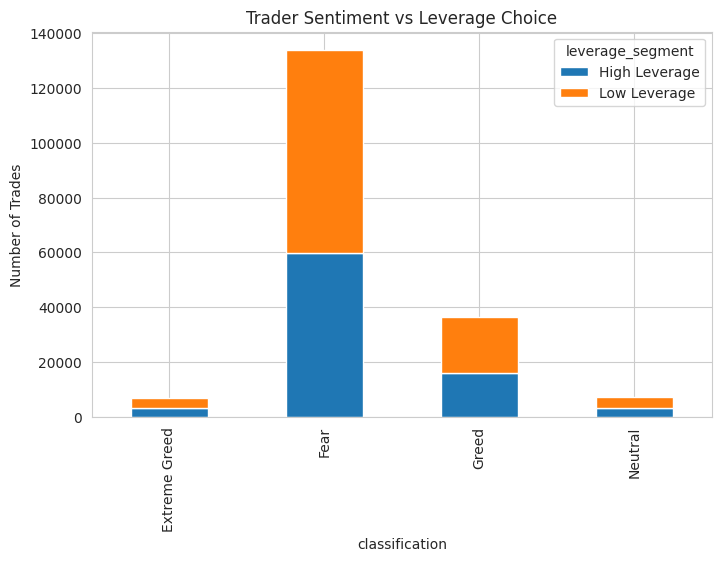

In [55]:
sentiment_lev = data.groupby(['classification', 'leverage_segment']).size().unstack()
sentiment_lev.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Trader Sentiment vs Leverage Choice")
plt.ylabel("Number of Trades")
plt.show()

Text(0.5, 1.0, 'Average PnL by Sentiment')

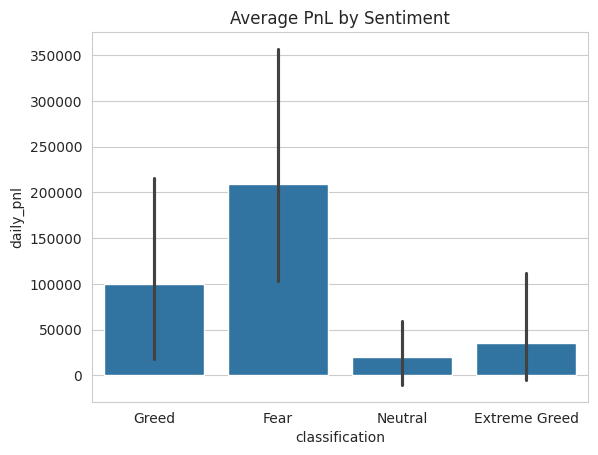

In [70]:
sns.barplot(data=metrics, x='classification', y='daily_pnl')
plt.title("Average PnL by Sentiment")

In [44]:
trader_activity = data.groupby('Account').size().reset_index(name='trade_count')
threshold = trader_activity['trade_count'].median()
trader_activity['activity_type'] = np.where(
    trader_activity['trade_count'] > threshold,
    'Frequent',
    'Infrequent'
)

In [45]:
pnl_std = daily_pnl.groupby('Account')['daily_pnl'].std().reset_index()
threshold = pnl_std['daily_pnl'].median()
pnl_std['consistency'] = np.where(
    pnl_std['daily_pnl'] < threshold,
    'Consistent',
    'Inconsistent'
)

In [46]:
long_short = data['Side'].value_counts(normalize=True)
print(long_short)

Side
SELL    0.513805
BUY     0.486195
Name: proportion, dtype: float64


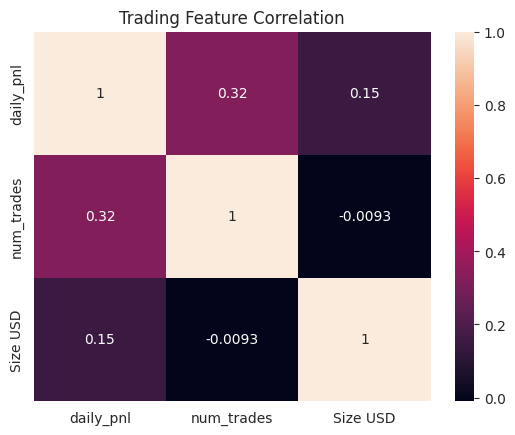

In [47]:
corr = metrics[['daily_pnl','num_trades','Size USD']].corr()
sns.heatmap(corr, annot=True)
plt.title("Trading Feature Correlation")
plt.show()

In [48]:
metrics.to_csv("final_data.csv", index=False)

In [57]:
metrics['profit_label'] = (metrics['daily_pnl'] > 0).astype(int)
metrics.head()

,Account,date,daily_pnl,num_trades,Size USD,classification,win,profit_label
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,-3.275059e+05,462,14810.891818,Greed,False,0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1.927736e+06,3356,16345.241940,Fear,True,1
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,2.060745e+04,320,2492.749906,Greed,True,1
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,1.709873e+04,3533,1693.351684,Fear,True,1
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-06-15,1.017915e+04,3427,1533.468395,NaN,True,1


In [58]:
metrics['sentiment'] = metrics['classification'].map({
    'Fear':0,
    'Greed':1
})

In [61]:
features = metrics[['num_trades','Size USD','sentiment']]
target = metrics['profit_label']

In [62]:
metrics_ml = metrics.dropna(subset=['sentiment'])

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

metrics_ml = metrics.dropna(subset=['sentiment'])

X = metrics_ml[['num_trades','Size USD','sentiment']]
y = metrics_ml['profit_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier()

model.fit(X_train,y_train)

pred = model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred))

Accuracy: 0.9230769230769231


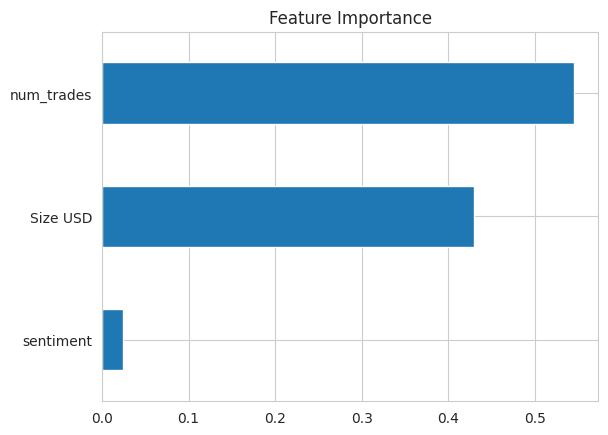

In [64]:
importance = pd.Series(model.feature_importances_, index=X.columns)

importance.sort_values().plot(kind='barh')

plt.title("Feature Importance")

plt.show()

In [65]:
X = metrics_ml[['num_trades','Size USD','sentiment','daily_pnl']]

In [66]:
trader_features = data.groupby('Account').agg({
    'Closed PnL':'mean',
    'Size USD':'mean',
    'Side':'count'
}).reset_index()

trader_features.rename(columns={
    'Side':'trade_count'
},inplace=True)

In [67]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    trader_features[['Closed PnL','Size USD','trade_count']]
)

In [68]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

trader_features['cluster'] = kmeans.fit_predict(scaled_features)

trader_features.head()

,Account,Closed PnL,Size USD,trade_count,cluster
0,0x083384f897ee0f19899168e3b1bec365f52a9012,419.127768,16159.576734,3818,0
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,6.577654,1653.226327,7280,2
2,0x271b280974205ca63b716753467d5a371de622ab,-18.492043,8893.000898,3809,2
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,9.951530,507.626933,13311,1
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,52.071011,3138.894782,3239,2


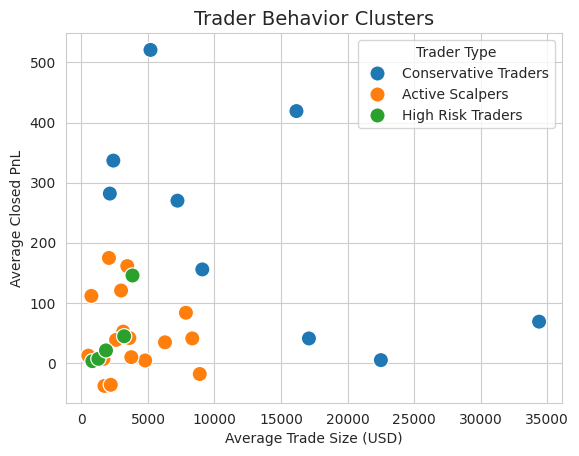

In [73]:
cluster_labels = {
    0: "Conservative Traders",
    1: "High Risk Traders",
    2: "Active Scalpers"
}

trader_features['cluster_label'] = trader_features['cluster'].map(cluster_labels)

sns.scatterplot(
    data=trader_features,
    x='Size USD',
    y='Closed PnL',
    hue='cluster_label',
    s=120
)

plt.title("Trader Behavior Clusters", fontsize=14)
plt.xlabel("Average Trade Size (USD)")
plt.ylabel("Average Closed PnL")
plt.legend(title="Trader Type")

plt.show()

In [74]:
trader_features.groupby('cluster_label')[['Closed PnL','Size USD','trade_count']].mean()

,Closed PnL,Size USD,trade_count
cluster_label,,,
Active Scalpers,46.901657,3798.753518,3160.529412
Conservative Traders,233.143261,12909.012165,4163.555556
High Risk Traders,38.390661,1915.636756,20003.833333
